In [ ]:
!ls /kaggle/input/datasets/dravyareddy/brats-2023

In [ ]:
data_dir = "/kaggle/input/datasets/dravyareddy/brats-2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"

In [ ]:
import os

base_path = "/kaggle/input/datasets/dravyareddy/brats-2023"

train_folder = "ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"

level1 = os.path.join(base_path, train_folder)

print("Inside Level 1:", os.listdir(level1))

# Go one more level down
level2 = os.path.join(level1, os.listdir(level1)[0])

cases = os.listdir(level2)

print("Total training cases:", len(cases))
print("First 5 cases:", cases[:5])

In [ ]:
!pip install -q monai nibabel

In [ ]:
!pip uninstall -y monai
!pip install monai==1.4.0

In [ ]:
# Remove broken stuff
!pip uninstall -y torch torchvision torchaudio monai numpy scipy scikit-learn nibabel

# Install stable stack
!pip install numpy==1.26.4 scipy==1.11.4 scikit-learn==1.3.2 nibabel==5.2.1

# PyTorch (P100 compatible)
!pip install torch==2.3.1+cu118 torchvision==0.18.1+cu118 torchaudio==2.3.1 \
    --index-url https://download.pytorch.org/whl/cu118

# MONAI (Python 3.12 FIXED)
!pip install monai==1.4.0

In [33]:
import torch, monai, numpy as np

print(torch.__version__)
print(monai.__version__)
print(np.__version__)

2.3.1+cu118
1.4.0
1.26.4


In [5]:


# =============================
# 🔥 1. IMPORTS
# =============================
import os
import torch
import numpy as np
from glob import glob
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    Orientationd, NormalizeIntensityd,
    CropForegroundd, RandCropByPosNegLabeld,
    ToTensord
)
from monai.data import CacheDataset, DataLoader
from monai.networks.nets import SwinUNETR
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from monai.transforms import AsDiscrete

# =============================
# 🔥 2. DEVICE
# =============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =============================
# 🔥 3. LOAD DATA
# =============================
train_path = "/kaggle/input/datasets/dravyareddy/brats-2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"

cases = sorted(glob(os.path.join(train_path, "*")))

def get_file(case, keyword):
    for f in os.listdir(case):
        if keyword in f and (f.endswith(".nii") or f.endswith(".nii.gz")):
            path = os.path.join(case, f)
            if os.path.getsize(path) > 0:
                return path
    return None

data = []
for case in cases:
    flair = get_file(case, "t2f")
    t1    = get_file(case, "t1n")
    t1ce  = get_file(case, "t1c")
    t2    = get_file(case, "t2w")
    seg   = get_file(case, "seg")

    if None not in [flair, t1, t1ce, t2, seg]:
        data.append({
            "image": [flair, t1, t1ce, t2],
            "label": seg
        })

print("Valid cases:", len(data))

# 🔥 USE SUBSET (faster + stable)
data = data[:100]

train_files, val_files = train_test_split(data, test_size=0.2, random_state=42)

# =============================
# 🔥 4. TRANSFORMS
# =============================
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(96, 96, 96),   # 🔥 bigger context → better learning
        pos=1,
        neg=1,
        num_samples=1,
    ),
    ToTensord(keys=["image", "label"])
])

val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    ToTensord(keys=["image", "label"])
])

# =============================
# 🔥 5. DATASETS
# =============================
train_ds = CacheDataset(train_files, train_transforms, cache_rate=1.0, num_workers=2)
val_ds   = CacheDataset(val_files, val_transforms, cache_rate=1.0, num_workers=2)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=1, num_workers=2, pin_memory=True)

# =============================
# 🔥 6. MODEL (OPTIMIZED)
# =============================
model = SwinUNETR(
    img_size=(96,96,96),
    in_channels=4,
    out_channels=4,
    feature_size=12,   # 🔥 KEY CHANGE (stable on P100)
    spatial_dims=3
).to(device)

print("Model loaded")

# =============================
# 🔥 7. LOSS + OPTIMIZER
# =============================
loss_function = DiceCELoss(
    to_onehot_y=True,
    softmax=True,
    include_background=False
)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dice_metric = DiceMetric(include_background=False, reduction="mean")

post_pred  = AsDiscrete(argmax=True, to_onehot=4)
post_label = AsDiscrete(to_onehot=4)

# =============================
# 🔥 8. TRAINING
# =============================
best_dice = 0
max_epochs = 50

for epoch in range(max_epochs):
    print(f"\nEpoch {epoch+1}/{max_epochs}")
    model.train()
    epoch_loss = 0

    for batch in train_loader:
        inputs = batch["image"].to(device).float()
        labels = batch["label"].to(device).long()

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    scheduler.step()
    print("Train Loss:", epoch_loss / len(train_loader))

    # =============================
    # 🔥 VALIDATION
    # =============================
    if (epoch + 1) % 5 == 0:
        model.eval()
        dice_metric.reset()

        with torch.no_grad():
            for val in val_loader:
                val_inputs = val["image"].to(device).float()
                val_labels = val["label"].to(device).long()

                val_outputs = sliding_window_inference(
                    val_inputs,
                    roi_size=(96,96,96),
                    sw_batch_size=2,
                    predictor=model
                )

                val_outputs = [post_pred(i) for i in val_outputs]
                val_labels  = [post_label(i) for i in val_labels]

                dice_metric(y_pred=val_outputs, y=val_labels)

        mean_dice = dice_metric.aggregate().item()
        dice_metric.reset()

        print("Val Dice:", mean_dice)

        if mean_dice > best_dice:
            best_dice = mean_dice
            torch.save(model.state_dict(), "/kaggle/working/best_model.pth")
            print("🔥 Saved best model")

print("Final Best Dice:", best_dice)

Device: cuda
Valid cases: 989


Loading dataset: 100%|██████████| 20/20 [00:24<00:00,  1.22s/it]


Model loaded

Epoch 1/50
Train Loss: 2.1062711760401727

Epoch 2/50
Train Loss: 1.8078704729676247

Epoch 3/50
Train Loss: 1.6511049017310142

Epoch 4/50
Train Loss: 1.4975789546966554

Epoch 5/50
Train Loss: 1.3651077598333359
Val Dice: 0.5590535998344421
🔥 Saved best model

Epoch 6/50
Train Loss: 1.2525904759764672

Epoch 7/50
Train Loss: 1.1660536617040633

Epoch 8/50
Train Loss: 1.0810431249439716

Epoch 9/50
Train Loss: 1.0093334034085273

Epoch 10/50
Train Loss: 0.9556920021772385
Val Dice: 0.5967303514480591
🔥 Saved best model

Epoch 11/50
Train Loss: 0.9362663559615612

Epoch 12/50
Train Loss: 0.8889659747481347

Epoch 13/50
Train Loss: 0.8292475938796997

Epoch 14/50
Train Loss: 0.7933625057339668

Epoch 15/50
Train Loss: 0.7894310168921947
Val Dice: 0.7091999650001526
🔥 Saved best model

Epoch 16/50
Train Loss: 0.7431874185800552

Epoch 17/50
Train Loss: 0.7007487155497074

Epoch 18/50
Train Loss: 0.7017051674425602

Epoch 19/50
Train Loss: 0.6604757618159056

Epoch 20/50
Tra

In [6]:
import os

print(os.listdir())

['.virtual_documents', 'best_model.pth']


Case: /kaggle/input/datasets/dravyareddy/brats-2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/BraTS-GLI-00016-001
✅ Model loaded
Unique pred values: [0 1 2 3]
WT: 70593 | TC: 32000 | ET: 27565
✅ Best tumor slice: 62 (out of 155)


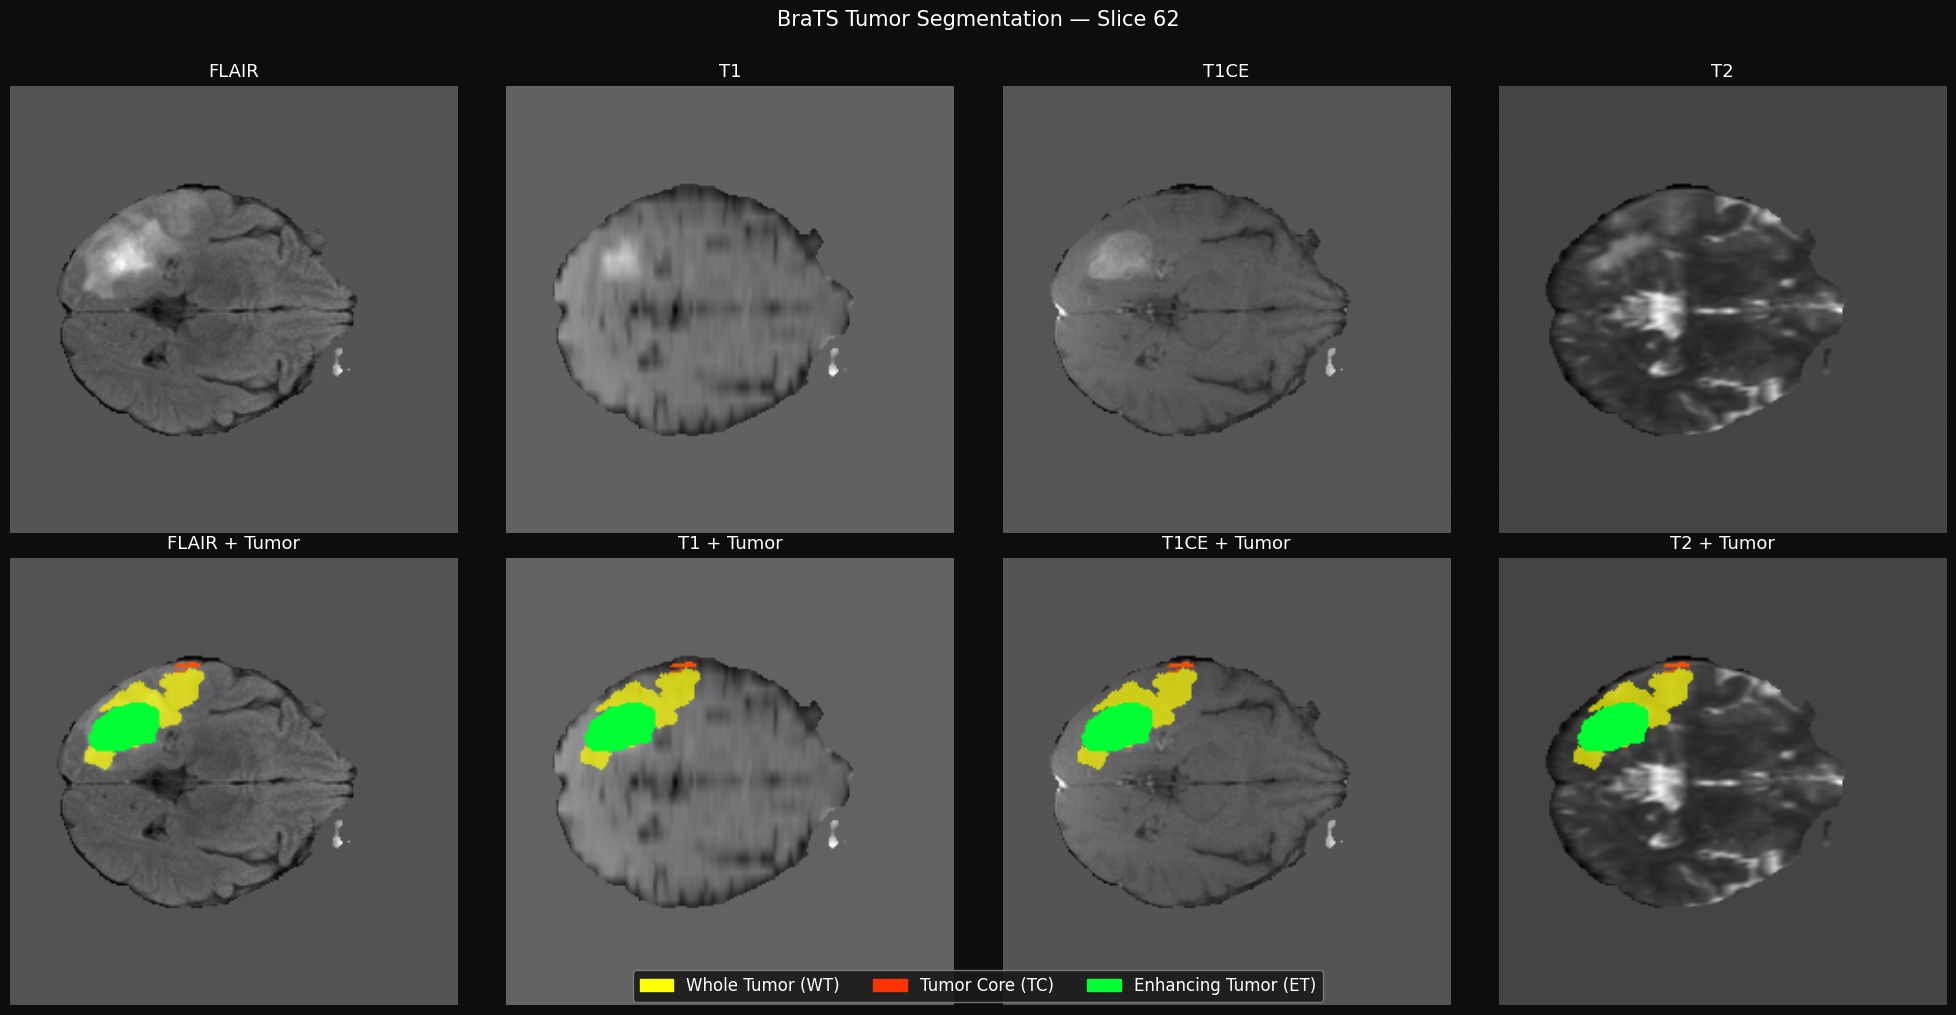

✅ Saved to tumor_overlay.png


In [23]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from scipy.ndimage import label as scipy_label

from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    Orientationd, NormalizeIntensityd, ToTensord
)
from monai.inferers import sliding_window_inference
from monai.networks.nets import SwinUNETR

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# LOAD CASE
# -------------------------
base_path = "/kaggle/input/datasets/dravyareddy/brats-2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"
cases = sorted(glob(os.path.join(base_path, "*")))

def get_file(case_path, keyword):
    for f in os.listdir(case_path):
        full = os.path.join(case_path, f)
        if keyword in f and (f.endswith(".nii") or f.endswith(".nii.gz")):
            if os.path.getsize(full) > 0:
                return full
    raise ValueError(f"{keyword} missing in {case_path}")

case_path = cases[14]
print("Case:", case_path)

data_dict = {
    "image": [
        get_file(case_path, "t2f"),
        get_file(case_path, "t1n"),
        get_file(case_path, "t1c"),
        get_file(case_path, "t2w"),
    ]
}

# -------------------------
# MODEL
# -------------------------
model = SwinUNETR(
    img_size=(64, 64, 64),
    in_channels=4,
    out_channels=4,
    feature_size=12,
    spatial_dims=3
).to(device)

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()
print("✅ Model loaded")

# -------------------------
# TRANSFORMS + INFERENCE
# -------------------------
transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys="image"),
    Orientationd(keys="image", axcodes="RAS"),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    ToTensord(keys="image")
])

data    = transforms(data_dict)
image   = data["image"]
if hasattr(image, "as_tensor"):
    image = image.as_tensor()
image = image.unsqueeze(0).to(device).float()

with torch.no_grad():
    logits = sliding_window_inference(
        image,
        roi_size=(64, 64, 64),
        sw_batch_size=1,
        predictor=model,
        overlap=0.5
    )

pred = torch.softmax(logits, dim=1).argmax(dim=1).cpu().numpy()[0]
img_np = image.cpu().numpy()[0]

print("Unique pred values:", np.unique(pred))

# -------------------------
# CLEAN SMALL REGIONS
# -------------------------
def remove_small_regions(mask, min_size=500):
    labeled, num = scipy_label(mask)
    out = np.zeros_like(mask)
    for i in range(1, num + 1):
        if (labeled == i).sum() > min_size:
            out[labeled == i] = 1
    return out

wt = remove_small_regions(pred > 0)
tc = remove_small_regions((pred == 1) | (pred == 3))
et = remove_small_regions(pred == 3)

print(f"WT: {wt.sum()} | TC: {tc.sum()} | ET: {et.sum()}")

# -------------------------
# 🔥 FIX 1: Find best slice (most tumor, not middle)
# -------------------------
tumor_per_slice = wt.sum(axis=(0, 1))
if tumor_per_slice.max() == 0:
    slice_idx = pred.shape[-1] // 2
    print("⚠️ No tumor found — showing middle slice")
else:
    slice_idx = int(tumor_per_slice.argmax())
    print(f"✅ Best tumor slice: {slice_idx} (out of {pred.shape[-1]})")

# -------------------------
# NORMALIZE HELPER
# -------------------------
def norm(x):
    mn, mx = x.min(), x.max()
    return (x - mn) / (mx - mn + 1e-8)

# -------------------------
# 🔥 FIX 2: Proper color overlay per modality
# -------------------------
modality_names = ["FLAIR", "T1", "T1CE", "T2"]

def make_overlay(gray_slice, wt_s, tc_s, et_s):
    """Build RGB overlay on top of a grayscale slice."""
    base = norm(gray_slice)
    rgb  = np.stack([base, base, base], axis=-1).copy()
    # whole tumor → yellow (semi-transparent)
    rgb[wt_s > 0] = rgb[wt_s > 0] * 0.3 + np.array([1.0, 1.0, 0.0]) * 0.7
    # tumor core → red
    rgb[tc_s > 0] = rgb[tc_s > 0] * 0.2 + np.array([1.0, 0.2, 0.0]) * 0.8
    # enhancing tumor → bright green
    rgb[et_s > 0] = np.array([0.0, 1.0, 0.2])
    return np.clip(rgb, 0, 1)

wt_s = wt[:, :, slice_idx]
tc_s = tc[:, :, slice_idx]
et_s = et[:, :, slice_idx]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.patch.set_facecolor("#0d0d0d")

for i, (name, ax_top, ax_bot) in enumerate(
    zip(modality_names, axes[0], axes[1])
):
    gray = img_np[i, :, :, slice_idx]
    overlay = make_overlay(gray, wt_s, tc_s, et_s)

    # top row — raw MRI
    ax_top.imshow(gray, cmap="gray", interpolation="bilinear")
    ax_top.set_title(name, color="white", fontsize=13, pad=6)
    ax_top.axis("off")

    # bottom row — overlay
    ax_bot.imshow(overlay, interpolation="bilinear")
    ax_bot.set_title(f"{name} + Tumor", color="white", fontsize=13, pad=6)
    ax_bot.axis("off")

# Legend
from matplotlib.patches import Patch
legend = [
    Patch(color=[1,1,0],   label="Whole Tumor (WT)"),
    Patch(color=[1,0.2,0], label="Tumor Core (TC)"),
    Patch(color=[0,1,0.2], label="Enhancing Tumor (ET)"),
]
fig.legend(handles=legend, loc="lower center", ncol=3,
           fontsize=12, facecolor="#1a1a1a", edgecolor="gray",
           labelcolor="white", framealpha=0.9,
           bbox_to_anchor=(0.5, 0.01))

plt.suptitle(f"BraTS Tumor Segmentation — Slice {slice_idx}",
             color="white", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("tumor_overlay.png", dpi=150, bbox_inches="tight",
            facecolor="#0d0d0d")
plt.show()
print("✅ Saved to tumor_overlay.png")

Case: /kaggle/input/datasets/dravyareddy/brats-2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/BraTS-GLI-00021-001
Model loaded
Unique labels: [0 1 2 3]
WT: 109013 | TC: 37436 | ET: 17410
Slices: [55, 62, 69]


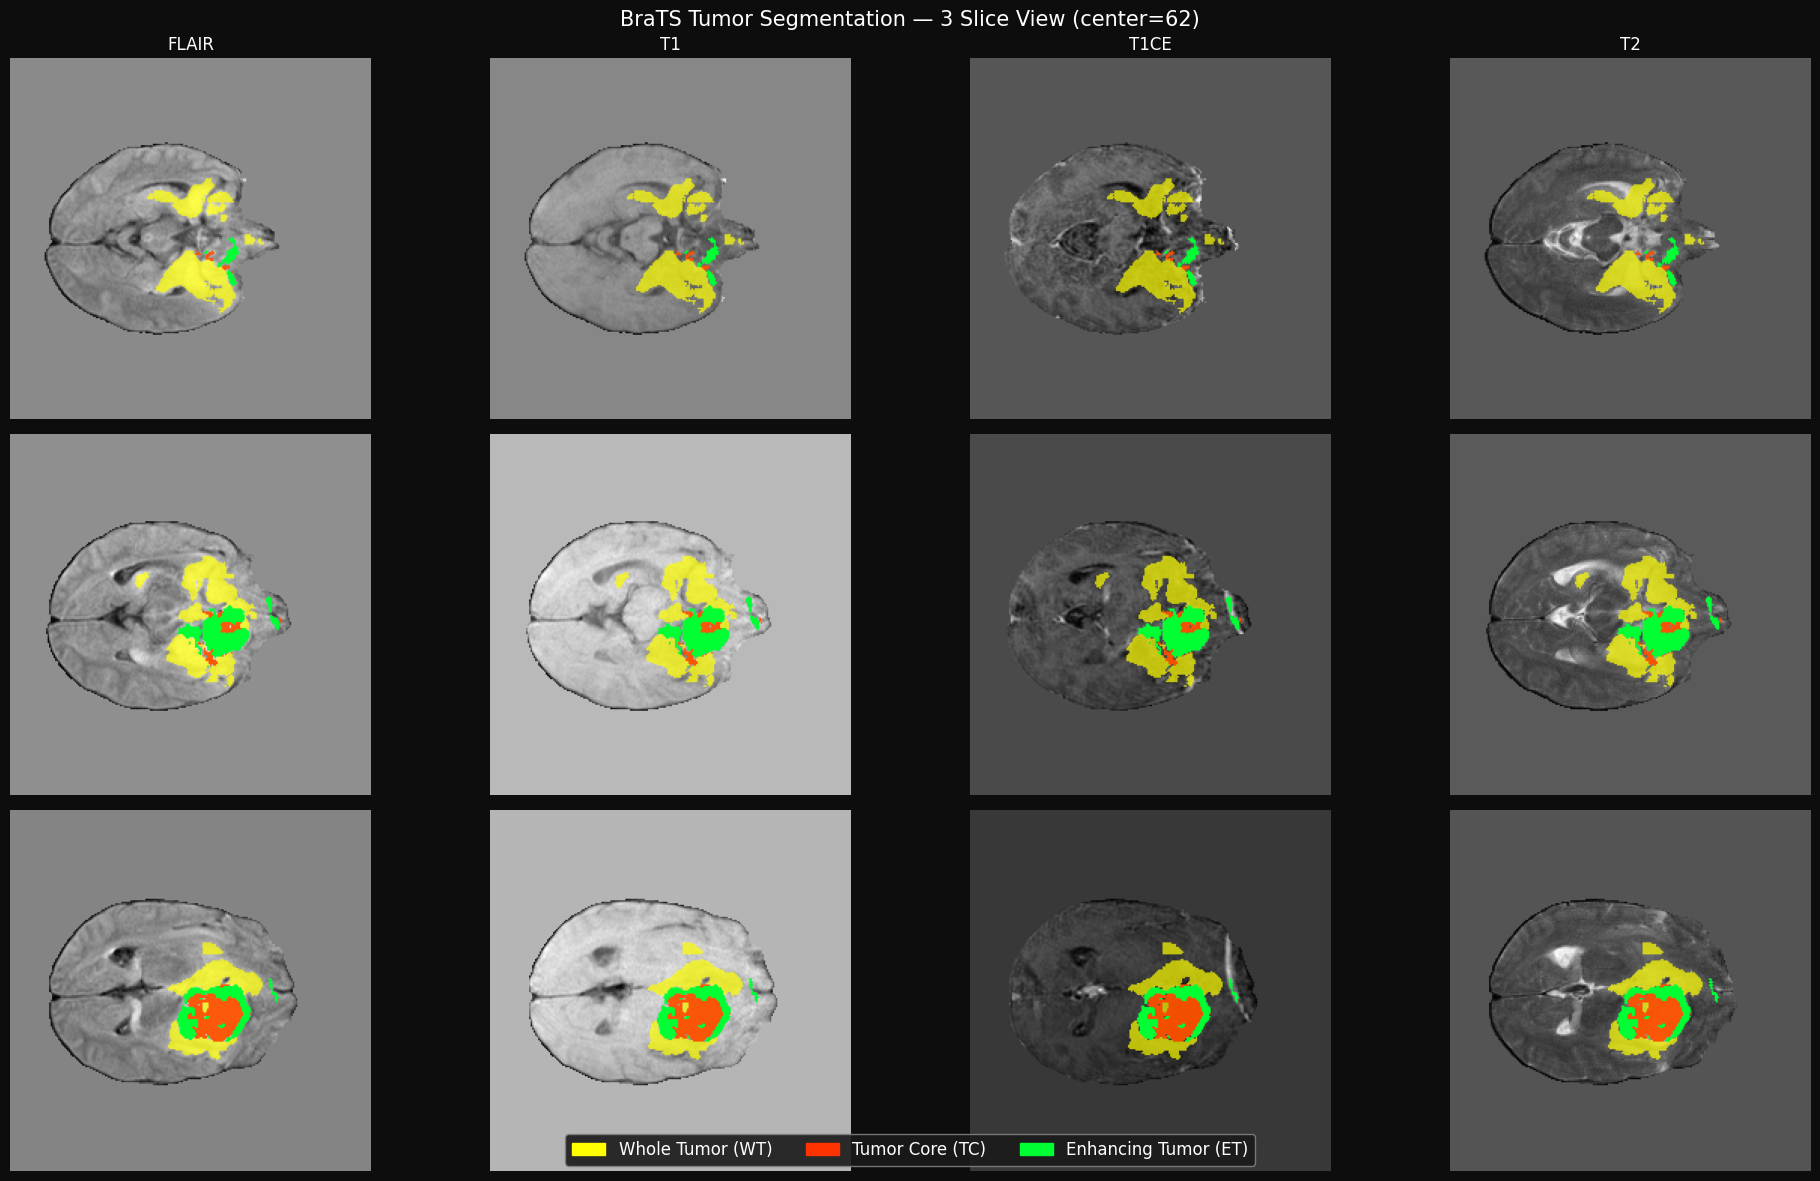

Saved → tumor_3slice_view.png


In [35]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from scipy.ndimage import label as scipy_label

from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    Orientationd, NormalizeIntensityd, ToTensord
)
from monai.inferers import sliding_window_inference
from monai.networks.nets import SwinUNETR

# -------------------------
# DEVICE
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# LOAD CASE
# -------------------------
base_path = "/kaggle/input/datasets/dravyareddy/brats-2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"
cases = sorted(glob(os.path.join(base_path, "*")))

def get_file(case_path, keyword):
    for f in os.listdir(case_path):
        full = os.path.join(case_path, f)
        if keyword in f and (f.endswith(".nii") or f.endswith(".nii.gz")):
            if os.path.getsize(full) > 0:
                return full
    raise ValueError(f"{keyword} missing in {case_path}")

# change index for different patient
case_path = cases[22]
print("Case:", case_path)

data_dict = {
    "image": [
        get_file(case_path, "t2f"),  # FLAIR
        get_file(case_path, "t1n"),  # T1
        get_file(case_path, "t1c"),  # T1CE
        get_file(case_path, "t2w"),  # T2
    ]
}

# -------------------------
# MODEL (must match training)
# -------------------------
model = SwinUNETR(
    img_size=(64, 64, 64),
    in_channels=4,
    out_channels=4,
    feature_size=12,
    spatial_dims=3
).to(device)

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()
print("Model loaded")

# -------------------------
# TRANSFORMS
# -------------------------
transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys="image"),
    Orientationd(keys="image", axcodes="RAS"),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    ToTensord(keys="image")
])

data  = transforms(data_dict)
image = data["image"]

if hasattr(image, "as_tensor"):
    image = image.as_tensor()

image = image.unsqueeze(0).to(device).float()

# -------------------------
# INFERENCE
# -------------------------
with torch.no_grad():
    logits = sliding_window_inference(
        image,
        roi_size=(64, 64, 64),
        sw_batch_size=1,
        predictor=model,
        overlap=0.5
    )

pred   = torch.softmax(logits, dim=1).argmax(dim=1).cpu().numpy()[0]
img_np = image.cpu().numpy()[0]

print("Unique labels:", np.unique(pred))

# -------------------------
# REMOVE SMALL REGIONS
# -------------------------
def remove_small_regions(mask, min_size=500):
    labeled, num = scipy_label(mask)
    out = np.zeros_like(mask)
    for i in range(1, num + 1):
        if (labeled == i).sum() > min_size:
            out[labeled == i] = 1
    return out

wt = remove_small_regions(pred > 0)
tc = remove_small_regions((pred == 1) | (pred == 3))
et = remove_small_regions(pred == 3)

print(f"WT: {wt.sum()} | TC: {tc.sum()} | ET: {et.sum()}")

# -------------------------
# FIND 3 SLICES (before / peak / after)
# -------------------------
tumor_per_slice = wt.sum(axis=(0, 1))

if tumor_per_slice.max() == 0:
    center = pred.shape[-1] // 2
    print("No tumor detected → using center slice")
else:
    center = int(tumor_per_slice.argmax())

offset = max(3, pred.shape[-1] // 20)

slice_indices = [
    max(center - offset, 0),
    center,
    min(center + offset, pred.shape[-1] - 1)
]

print(f"Slices:", slice_indices)

# -------------------------
# NORMALIZATION
# -------------------------
def norm(x):
    mn, mx = x.min(), x.max()
    return (x - mn) / (mx - mn + 1e-8)

# -------------------------
# OVERLAY FUNCTION
# -------------------------
def make_overlay(gray, wt_s, tc_s, et_s):
    base = norm(gray)
    rgb  = np.stack([base, base, base], axis=-1).copy()

    # Whole tumor → Yellow
    rgb[wt_s > 0] = rgb[wt_s > 0] * 0.3 + np.array([1, 1, 0]) * 0.7

    # Tumor core → Red
    rgb[tc_s > 0] = rgb[tc_s > 0] * 0.2 + np.array([1, 0.2, 0]) * 0.8

    # Enhancing tumor → Green
    rgb[et_s > 0] = np.array([0, 1, 0.2])

    return np.clip(rgb, 0, 1)

# -------------------------
# VISUALIZATION (3 slices × 4 modalities)
# -------------------------
modality_names = ["FLAIR", "T1", "T1CE", "T2"]

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.patch.set_facecolor("#0d0d0d")

for row, s_idx in enumerate(slice_indices):

    wt_s = wt[:, :, s_idx]
    tc_s = tc[:, :, s_idx]
    et_s = et[:, :, s_idx]

    for col in range(4):
        gray = img_np[col, :, :, s_idx]
        overlay = make_overlay(gray, wt_s, tc_s, et_s)

        ax = axes[row, col]
        ax.imshow(overlay)
        ax.axis("off")

        if row == 0:
            ax.set_title(modality_names[col], color="white", fontsize=12)

        if col == 0:
            label = ["Before", "Peak", "After"][row]
            ax.set_ylabel(f"{label}\n(z={s_idx})",
                          color="white", fontsize=12)

# -------------------------
# LEGEND
# -------------------------
from matplotlib.patches import Patch

legend = [
    Patch(color=[1,1,0],   label="Whole Tumor (WT)"),
    Patch(color=[1,0.2,0], label="Tumor Core (TC)"),
    Patch(color=[0,1,0.2], label="Enhancing Tumor (ET)"),
]

fig.legend(
    handles=legend,
    loc="lower center",
    ncol=3,
    fontsize=12,
    facecolor="#1a1a1a",
    edgecolor="gray",
    labelcolor="white",
    framealpha=0.9,
    bbox_to_anchor=(0.5, 0.01)
)

plt.suptitle(
    f"BraTS Tumor Segmentation — 3 Slice View (center={center})",
    color="white",
    fontsize=15
)

plt.tight_layout()
plt.savefig(
    "tumor_3slice_view.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="#0d0d0d"
)

plt.show()

print("Saved → tumor_3slice_view.png")